# Fig2 Hotfish Validation Figure Components

Recapitulates selected 20260528 SAC figures and writes the reformatted outputs to the Fig2 Hotfish validation Google Drive component folder.

Source figure code:
- `results/nlammers/20260528/hotfish_morph_plots_v3.ipynb`, cell 30: `hooke_branch_contrast`
- `results/nlammers/20260528/05_presentation_sac_figs.ipynb`, cell 17: `03_final_population_means_and_se`
- `results/nlammers/20260528/05_presentation_sac_figs.ipynb`, cell 8: `01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac`
- `results/nlammers/20260528/05_presentation_sac_figs.ipynb`, cell 33: `04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection`

Source datasets:
- `/Users/nick/Projects/data/morphseq/results/20260528/hotfish_morph_ccs_contrast.csv`
- `/Users/nick/Projects/data/morphseq/results/20260528/joint_141_morph_seq.csv`
- `/Users/nick/Projects/data/morphseq/results/20260528/tempo_noise_cohort_summary_bootstrap_se.csv`


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
import numpy as np
import pandas as pd

SOURCE_CACHE_DIR = Path('/Users/nick/Projects/data/morphseq/results/20260528')
OUT_DIR = Path('/Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRAST_PATH = SOURCE_CACHE_DIR / 'hotfish_morph_ccs_contrast.csv'
JOINT_PATH = SOURCE_CACHE_DIR / 'joint_141_morph_seq.csv'
COHORT_BOOTSTRAP_PATH = SOURCE_CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se.csv'

SOURCE_NOTEBOOKS = {
    'hooke_branch_contrast': Path('/Users/nick/Projects/repositories/morphseq/results/nlammers/20260528/hotfish_morph_plots_v3.ipynb'),
    'stage_panels': Path('/Users/nick/Projects/repositories/morphseq/results/nlammers/20260528/05_presentation_sac_figs.ipynb'),
}

TEMP_CMAP = 'RdBu_r'
TEMP_VMIN = 24
TEMP_CENTER = 28.5
TEMP_VMAX = 35
TIMEPOINT_MARKERS = {24.0: 'o', 30.0: 's', 36.0: '^'}
BOOTSTRAP_SEED = 20260528
BOOTSTRAP_N = 5000

FONT_SCALE = 2.0
mpl.rcParams.update(
    {
        'font.family': 'Arial',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'font.size': 15 * FONT_SCALE,
        'axes.labelsize': 16.5 * FONT_SCALE,
        'xtick.labelsize': 15 * FONT_SCALE,
        'ytick.labelsize': 15 * FONT_SCALE,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.edgecolor': 'black',
        'axes.grid': False,
        'grid.alpha': 0,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'savefig.facecolor': 'white',
        'savefig.bbox': 'tight',
    }
)

print(f'Writing figures to: {OUT_DIR}')
print(f'Hooke contrast data: {CONTRAST_PATH}')
print(f'Joint morph/seq data: {JOINT_PATH}')
print(f'Stage variability cohort data: {COHORT_BOOTSTRAP_PATH}')


Writing figures to: /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation
Hooke contrast data: /Users/nick/Projects/data/morphseq/results/20260528/hotfish_morph_ccs_contrast.csv
Joint morph/seq data: /Users/nick/Projects/data/morphseq/results/20260528/joint_141_morph_seq.csv
Stage variability cohort data: /Users/nick/Projects/data/morphseq/results/20260528/tempo_noise_cohort_summary_bootstrap_se.csv


In [2]:
def temperature_norm():
    return mpl.colors.TwoSlopeNorm(vmin=TEMP_VMIN, vcenter=TEMP_CENTER, vmax=TEMP_VMAX)


def save_figure(fig, output_stem, *, output_dir=OUT_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)
    for suffix in ('png', 'pdf'):
        output_path = output_dir / f'{output_stem}.{suffix}'
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f'Saved {output_path}')


def marker_for_timepoint(timepoint):
    return TIMEPOINT_MARKERS.get(float(timepoint), 'o')


def add_black_arrow_axes(ax, *, linewidth=4.6):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=10,
        width=3.2,
        colors='black',
        bottom=True,
        left=True,
        top=False,
        right=False,
    )
    arrowprops = dict(
        arrowstyle='-|>',
        color='black',
        linewidth=linewidth,
        mutation_scale=34,
        shrinkA=0,
        shrinkB=0,
    )
    ax.annotate('', xy=(1.025, 0), xytext=(0, 0), xycoords='axes fraction', arrowprops=arrowprops, annotation_clip=False)
    ax.annotate('', xy=(0, 1.025), xytext=(0, 0), xycoords='axes fraction', arrowprops=arrowprops, annotation_clip=False)


def add_identity(ax, *, linewidth=3.6):
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=linewidth, zorder=1)


def style_stage_axes(ax, *, axis_min=20, axis_max=43, show_diagonal=True):
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    ax.set_xticks([20, 30, 40])
    ax.set_yticks([20, 30, 40])
    ax.set_xlabel('morphology-inferred\nstage (hpf)')
    ax.set_ylabel('transcription-inferred\nstage (hpf)')
    if show_diagonal:
        add_identity(ax)
    add_black_arrow_axes(ax)


def scatter_by_timepoint(ax, data, x, y, *, size, alpha, linewidth, zorder, rasterized=True):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    for timepoint, group in data.groupby('timepoint', sort=True):
        ax.scatter(
            group[x],
            group[y],
            c=group['temperature'],
            cmap=cmap,
            norm=norm,
            marker=marker_for_timepoint(timepoint),
            s=size,
            alpha=alpha,
            edgecolor='black',
            linewidth=linewidth,
            rasterized=rasterized,
            zorder=zorder,
        )


In [3]:
contrast_df = pd.read_csv(CONTRAST_PATH)
contrast_df['delta_log_abund'] = -contrast_df['delta_log_abund']
contrast_df['delta_abund'] = np.exp(contrast_df['delta_log_abund'])
contrast_df['sig_flag'] = contrast_df['delta_q_value'] >= 0.05

cohort_boot_all = pd.read_csv(COHORT_BOOTSTRAP_PATH)
cohort_boot_all['temperature'] = cohort_boot_all['temperature'].astype(float)
cohort_boot_all['timepoint'] = cohort_boot_all['timepoint'].astype(float)

joint_all = pd.read_csv(JOINT_PATH)
joint_all['temperature'] = joint_all['temperature'].astype(float)
joint_all['timepoint'] = joint_all['timepoint'].astype(float)

reference_temperature = 28.5
reference_timepoints = [24.0, 30.0, 36.0]
reference = joint_all.loc[
    joint_all['temperature'].eq(reference_temperature)
    & joint_all['timepoint'].isin(reference_timepoints)
].copy()

reference_means = (
    reference.groupby('timepoint', as_index=False)
    .agg(
        morph_stage_mean=('mdl_stage_hpf', 'mean'),
        seq_stage_mean=('pseudostage', 'mean'),
    )
)
reference_means['morph_offset'] = reference_means['morph_stage_mean'] - reference_means['timepoint']
reference_means['seq_offset'] = reference_means['seq_stage_mean'] - reference_means['timepoint']

morph_stage_offset = reference_means['morph_offset'].mean()
seq_stage_offset = reference_means['seq_offset'].mean()

joint_all['mdl_stage_hpf_registered'] = joint_all['mdl_stage_hpf'] - morph_stage_offset
joint_all['pseudostage_registered'] = joint_all['pseudostage'] - seq_stage_offset


def bootstrap_mean_se(values, rng, n_bootstrap=BOOTSTRAP_N):
    arr = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    if arr.size < 2:
        return np.nan
    samples = rng.choice(arr, size=(n_bootstrap, arr.size), replace=True)
    return float(np.std(np.mean(samples, axis=1), ddof=1))


rng = np.random.default_rng(BOOTSTRAP_SEED)
stage_group_all_rows = []
for (temperature, timepoint), group in joint_all.groupby(['temperature', 'timepoint'], sort=True):
    stage_group_all_rows.append(
        {
            'temperature': float(temperature),
            'timepoint': float(timepoint),
            'morph_stage_mean': group['mdl_stage_hpf'].mean(),
            'morph_stage_sd': group['mdl_stage_hpf'].std(ddof=1),
            'morph_stage_mean_boot_se': bootstrap_mean_se(group['mdl_stage_hpf'], rng),
            'seq_stage_mean': group['pseudostage'].mean(),
            'seq_stage_sd': group['pseudostage'].std(ddof=1),
            'seq_stage_mean_boot_se': bootstrap_mean_se(group['pseudostage'], rng),
            'n': group['snip_id'].count(),
        }
    )

stage_group_all = pd.DataFrame(stage_group_all_rows)
stage_group_all['morph_stage_mean_registered'] = stage_group_all['morph_stage_mean'] - morph_stage_offset
stage_group_all['seq_stage_mean_registered'] = stage_group_all['seq_stage_mean'] - seq_stage_offset


def early_timepoint_mask(data):
    return (
        np.isclose(data['temperature'].astype(float), 19.0)
        | (
            np.isclose(data['temperature'].astype(float), 25.0)
            & np.isclose(data['timepoint'].astype(float), 24.0)
        )
    )

cohort_boot_without_19c_25c24 = cohort_boot_all.loc[~early_timepoint_mask(cohort_boot_all)].copy()
stage_panel_individuals = joint_all.loc[~early_timepoint_mask(joint_all)].copy()
stage_panel_groups = stage_group_all.loc[~early_timepoint_mask(stage_group_all)].copy()

print(f'Hooke contrast rows: {len(contrast_df)}')
print(f'Joint embryos: {len(joint_all)}')
print(f'Stage-variability cohorts after original no-early filter: {len(cohort_boot_without_19c_25c24)}')
print(f'Stage-panel embryos after original no-early filter: {len(stage_panel_individuals)}')
print(f'Stage-panel groups after original no-early filter: {len(stage_panel_groups)}')
print(f'Reference temperature: {reference_temperature:g}C')
print(f'Morphology stage offset: {morph_stage_offset:.3f} hpf')
print(f'Transcription stage offset: {seq_stage_offset:.3f} hpf')
reference_means


Hooke contrast rows: 288
Joint embryos: 141
Stage-variability cohorts after original no-early filter: 14
Stage-panel embryos after original no-early filter: 109
Stage-panel groups after original no-early filter: 14
Reference temperature: 28.5C
Morphology stage offset: -0.368 hpf
Transcription stage offset: 1.438 hpf


,timepoint,morph_stage_mean,seq_stage_mean,morph_offset,seq_offset
0,24.0,24.761971,26.304693,0.761971,2.304693
1,30.0,29.910695,31.478885,-0.089305,1.478885
2,36.0,34.222927,36.530674,-1.777073,0.530674


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/hooke_branch_contrast.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/hooke_branch_contrast.pdf


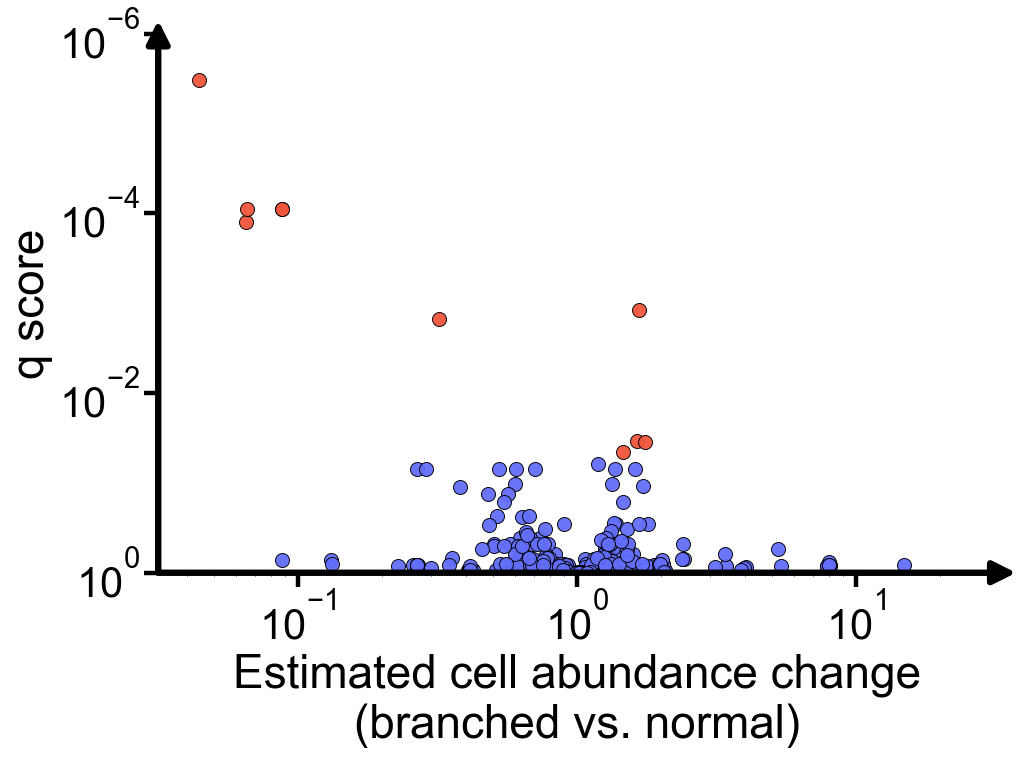

In [4]:
# hooke_branch_contrast.png
fig, ax = plt.subplots(figsize=(10.8, 7.0), facecolor='white')

sig_colors = {True: '#636EFA', False: '#EF553B'}
for sig_flag, plot_data in contrast_df.groupby('sig_flag', sort=False):
    ax.scatter(
        plot_data['delta_abund'],
        plot_data['delta_q_value'],
        s=102,
        color=sig_colors[bool(sig_flag)],
        edgecolor='black',
        linewidth=0.7,
        alpha=0.95,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10**-1.5, 10**1.5)
ax.set_ylim(1, 10**-6)
ax.set_xticks([0.1, 1, 10])
ax.set_yticks([1, 1e-2, 1e-4, 1e-6])
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.set_xlabel('Estimated cell abundance change\n(branched vs. normal)')
ax.set_ylabel('q score')
add_black_arrow_axes(ax)

save_figure(fig, 'hooke_branch_contrast')
plt.show()


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac.pdf


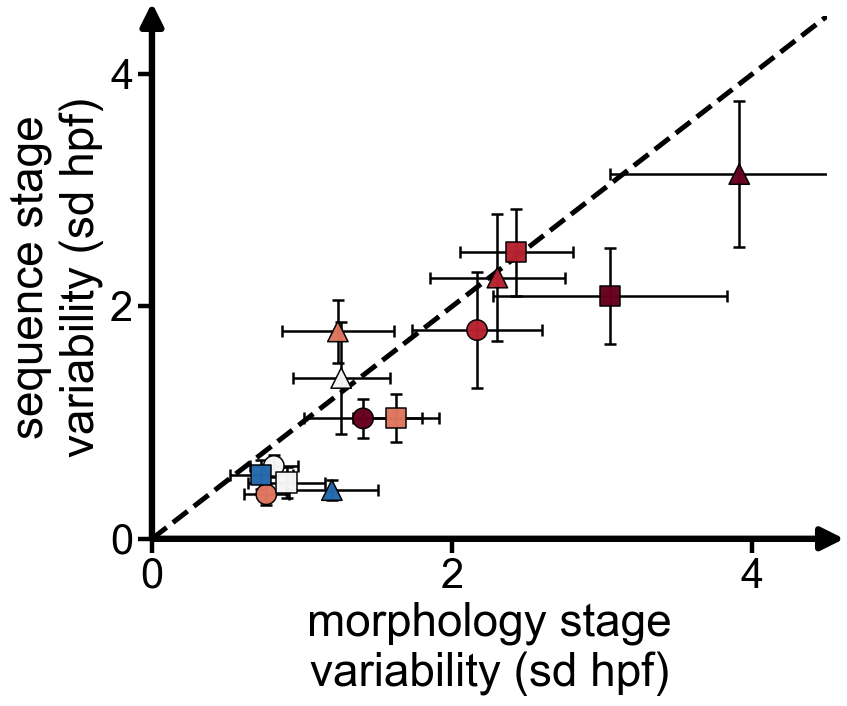

In [5]:
# 01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac.png
# Formatting update: collection is encoded by marker shape, not marker size; legends are omitted.
STAGING_VARIABILITY_AXIS_MAX = 4.5

fig, ax = plt.subplots(figsize=(9.2, 7.8), facecolor='white')

ax.errorbar(
    cohort_boot_without_19c_25c24['morph_stage_std'],
    cohort_boot_without_19c_25c24['seq_stage_std'],
    xerr=cohort_boot_without_19c_25c24['morph_stage_std_boot_se'],
    yerr=cohort_boot_without_19c_25c24['seq_stage_std_boot_se'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=1,
)

scatter_by_timepoint(
    ax,
    cohort_boot_without_19c_25c24,
    'morph_stage_std',
    'seq_stage_std',
    size=216,
    alpha=0.98,
    linewidth=1.1,
    zorder=2,
    rasterized=False,
)

ax.set_xlim(0, STAGING_VARIABILITY_AXIS_MAX)
ax.set_ylim(0, STAGING_VARIABILITY_AXIS_MAX)
ax.set_xticks([0, 2, 4])
ax.set_yticks([0, 2, 4])
ax.set_xlabel('morphology stage\nvariability (sd hpf)')
ax.set_ylabel('sequence stage\nvariability (sd hpf)')
add_identity(ax)
add_black_arrow_axes(ax)
fig.tight_layout()

save_figure(fig, '01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac')
plt.show()


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/03_final_population_means_and_se.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/03_final_population_means_and_se.pdf


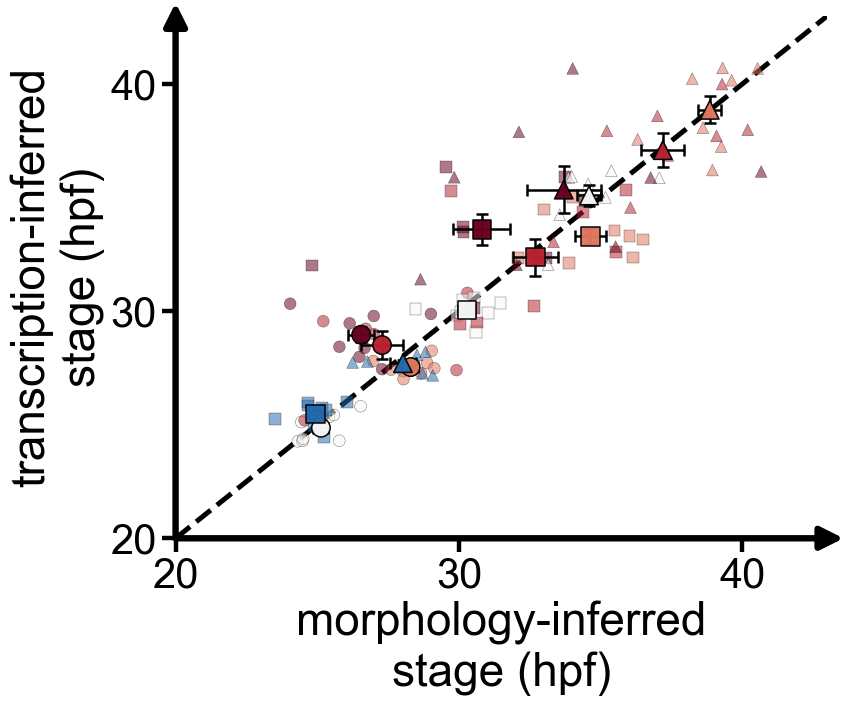

In [6]:
# 03_final_population_means_and_se.png, original no-early filter: no 19C and no 25C/24 hpf.
ANIMATION_AXIS_MIN = 20
ANIMATION_AXIS_MAX = 43
ANIMATION_BASELINE_Y = ANIMATION_AXIS_MIN + 0.65
ANIMATION_POINT_SIZE = 72
ANIMATION_POINT_ALPHA = 0.53

animation_data = stage_panel_individuals.sort_values(
    ['temperature', 'timepoint', 'mdl_stage_hpf_registered']
).reset_index(drop=True)
animation_group_data = stage_panel_groups.sort_values(['temperature', 'timepoint']).reset_index(drop=True)

initial_x = animation_data['mdl_stage_hpf_registered'].to_numpy()
final_y = animation_data['pseudostage_registered'].to_numpy()

plot_data = animation_data.copy()
plot_data['_animation_x'] = initial_x
plot_data['_animation_y'] = final_y

fig, ax = plt.subplots(figsize=(9.2, 7.8), facecolor='white')
scatter_by_timepoint(
    ax,
    plot_data,
    '_animation_x',
    '_animation_y',
    size=ANIMATION_POINT_SIZE,
    alpha=ANIMATION_POINT_ALPHA,
    linewidth=0.35,
    zorder=2,
)

ax.errorbar(
    animation_group_data['morph_stage_mean_registered'],
    animation_group_data['seq_stage_mean_registered'],
    xerr=animation_group_data['morph_stage_mean_boot_se'],
    yerr=animation_group_data['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=3,
)
scatter_by_timepoint(
    ax,
    animation_group_data,
    'morph_stage_mean_registered',
    'seq_stage_mean_registered',
    size=177,
    alpha=0.98,
    linewidth=1.1,
    zorder=4,
    rasterized=False,
)

style_stage_axes(ax, axis_min=ANIMATION_AXIS_MIN, axis_max=ANIMATION_AXIS_MAX, show_diagonal=True)
fig.tight_layout()
save_figure(fig, '03_final_population_means_and_se')
plt.show()


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection.pdf


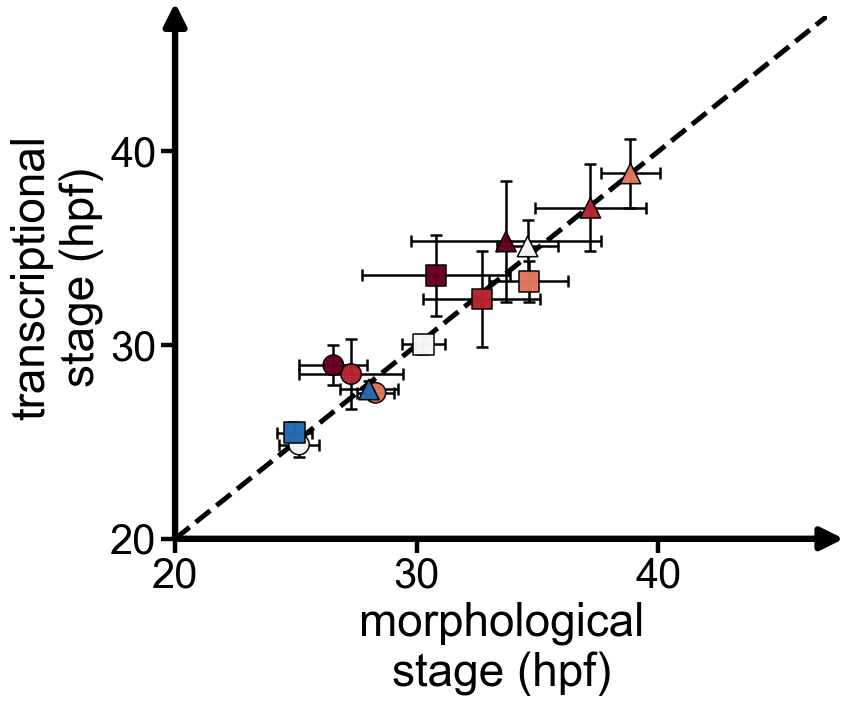

In [7]:
# 04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection.png
# Formatting update: collection is encoded by marker shape, not marker size; legends are omitted.
STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS = (20, 47)
stage_split_04_data = stage_panel_groups.sort_values(['timepoint', 'temperature']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.2, 7.8), facecolor='white')

ax.errorbar(
    stage_split_04_data['morph_stage_mean_registered'],
    stage_split_04_data['seq_stage_mean_registered'],
    xerr=stage_split_04_data['morph_stage_sd'],
    yerr=stage_split_04_data['seq_stage_sd'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=2,
)

scatter_by_timepoint(
    ax,
    stage_split_04_data,
    'morph_stage_mean_registered',
    'seq_stage_mean_registered',
    size=216,
    alpha=0.98,
    linewidth=1.1,
    zorder=3,
    rasterized=False,
)

ax.set_xlim(*STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS)
ax.set_ylim(*STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS)
ax.set_xticks([20, 30, 40])
ax.set_yticks([20, 30, 40])
ax.set_xlabel('morphological\nstage (hpf)')
ax.set_ylabel('transcriptional\nstage (hpf)')
add_identity(ax)
add_black_arrow_axes(ax)
fig.tight_layout()

save_figure(fig, '04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection')
plt.show()


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/offset_1d_gaussians.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/offset_1d_gaussians.pdf


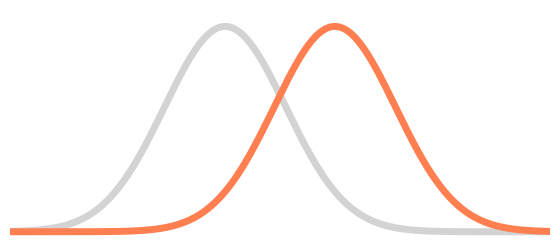

In [8]:
# offset_1d_gaussians.png
# Minimal two-curve schematic: no axes, labels, ticks, or legend.
x = np.linspace(-4.0, 4.0, 600)
sigma = 0.72
center_gray = -0.65
center_coral = 0.65

y_gray = np.exp(-0.5 * ((x - center_gray) / sigma) ** 2)
y_coral = np.exp(-0.5 * ((x - center_coral) / sigma) ** 2)

fig, ax = plt.subplots(figsize=(5.4, 2.3), facecolor='white')
ax.plot(x, y_gray, color='#D3D3D3', linewidth=5.0, solid_capstyle='round')
ax.plot(x, y_coral, color='#FF7F50', linewidth=5.0, solid_capstyle='round')
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.04, 1.08)
ax.axis('off')
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

save_figure(fig, 'offset_1d_gaussians')
plt.show()


Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/summed_offset_1d_gaussians.png
Saved /Users/nick/Library/CloudStorage/GoogleDrive-nlammers@uw.edu/My Drive/projects/K99/Materials/figure components/Fig2 hotfish validation/summed_offset_1d_gaussians.pdf


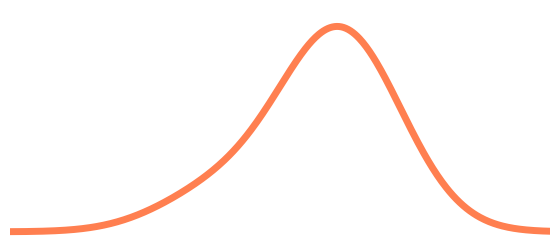

In [9]:
# summed_offset_1d_gaussians.png
# Sum of two offset 1D Gaussians, plotted as one curve with no axes or labels.
# Component centers are separated by 2 sigma; the right/coral-side component has 5x amplitude.
x = np.linspace(-4.0, 4.0, 600)
sigma = 0.72
center_gray = -sigma
center_coral = sigma
amplitude_gray = 1.0
amplitude_coral = 5.0

y_gray = amplitude_gray * np.exp(-0.5 * ((x - center_gray) / sigma) ** 2)
y_coral = amplitude_coral * np.exp(-0.5 * ((x - center_coral) / sigma) ** 2)
y_sum = y_gray + y_coral
y_sum = y_sum / y_sum.max()

fig, ax = plt.subplots(figsize=(5.4, 2.3), facecolor='white')
ax.plot(x, y_sum, color='#FF7F50', linewidth=5.0, solid_capstyle='round')
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.04, 1.08)
ax.axis('off')
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

save_figure(fig, 'summed_offset_1d_gaussians')
plt.show()
